# Spam SMS Collection

This project focuses on classifying SMS messages as spam or ham (not spam) using Natural Language Processing (NLP) techniques and multiple machine learning models. The objective is to compare different algorithms and identify the best-performing model.

- The goal of this project is to build a classification model that can accurately detect whether a given SMS message is spam or not. This helps in filtering unwanted messages and improving user experience.

## Dataset Description

The dataset used in this project is the SMS Spam Collection dataset. It contains labeled SMS messages categorized into:
- **Ham (0):** Normal messages
- **Spam (1):** Unwanted or promotional messages

The dataset consists of two main columns:
- `label`: Indicates whether the message is spam or ham
- `text`: The actual SMS message content

In [51]:
import pandas as pd

# Splitting dataset
from sklearn.model_selection import train_test_split

# Convert text into numerical features (important for NLP)
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation metric
from sklearn.metrics import accuracy_score

In [52]:
# Load the dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

# Keeping only required columns and renaming them
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data Preprocessing

Before training the models, the text data is cleaned and prepared:
- Converted all text to lowercase
- Removed special characters and numbers
- Removed extra spaces

This step ensures that the data is consistent and suitable for further processing.

In [53]:
import re

# Clean text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['text'] = df['text'].apply(clean_text)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [55]:
# Convert 'ham' → 0 and 'spam' → 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Check data
df.head()

,label,text
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final ...
3,0,u dun say so early hor u c already then say
4,0,nah i don t think he goes to usf he lives arou...


### Train-Test Split

The dataset is divided into training and testing sets:
- Training set 80% is used to train the models.
- Testing set 20% is used to evaluate performance

This ensures that the model is tested on unseen data.

In [70]:
# Split into training and testing data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], 
    test_size=0.2, 
    random_state=42
)

## Feature Extraction using TF-IDF

Text data cannot be directly used by machine learning models, so it is converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF helps in:
- Assigning importance to words
- Reducing the impact of common words
- Highlighting meaningful terms in messages

In [57]:
# Initialize TF-IDF vectorizer (removes common words like "the", "is")
tfidf = TfidfVectorizer(stop_words='english')

# Fit on training data and transform both train & test data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Model Training

Multiple machine learning models are used to solve the classification problem:

- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)
- Random Forest

Using multiple models helps in comparing performance and selecting the best one.

### Logistic Regression

In [58]:
# Initialize and train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Predict on test data
pred_lr = lr.predict(X_test_tfidf)

# Calculate accuracy
acc_lr = accuracy_score(y_test, pred_lr)

### Naive Bayes

In [59]:
# Initialize and train model
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Predict
pred_nb = nb.predict(X_test_tfidf)

# Accuracy
acc_nb = accuracy_score(y_test, pred_nb)

### Support Vector Machines (SVM)

In [60]:
# Initialize and train model
svm = SVC()
svm.fit(X_train_tfidf, y_train)

# Predict
pred_svm = svm.predict(X_test_tfidf)

# Accuracy
acc_svm = accuracy_score(y_test, pred_svm)

### Random Forest

In [61]:
# Initialize and train model
rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)

# Predict
pred_rf = rf.predict(X_test_tfidf)

# Accuracy
acc_rf = accuracy_score(y_test, pred_rf)

### Confusion Matrix

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_conf_matrix_rb(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    
    # Red-Blue color theme
    plt.imshow(cm, interpolation='nearest', cmap='coolwarm')
    
    # Title and labels
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    # Tick marks
    classes = ['Ham', 'Spam']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Add numbers inside boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="black")

    # Color bar
    plt.colorbar()

    plt.tight_layout()
    plt.show()

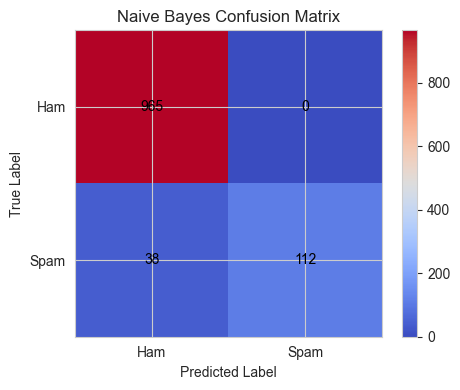

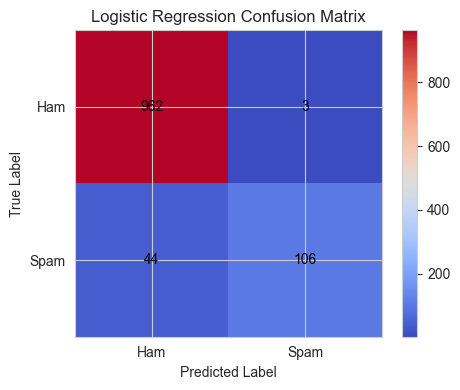

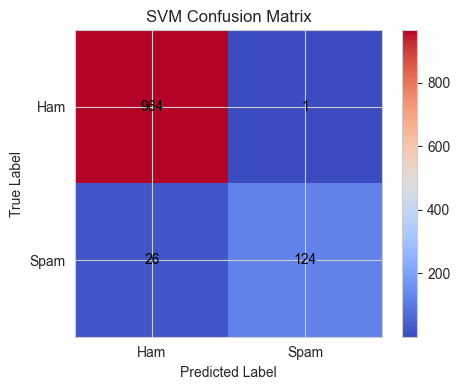

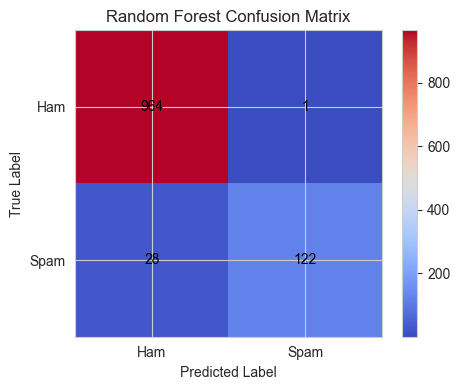

In [63]:
plot_conf_matrix_rb(y_test, pred_nb, "Naive Bayes Confusion Matrix")
plot_conf_matrix_rb(y_test, pred_lr, "Logistic Regression Confusion Matrix")
plot_conf_matrix_rb(y_test, pred_svm, "SVM Confusion Matrix")
plot_conf_matrix_rb(y_test, pred_rf, "Random Forest Confusion Matrix")

# Accuracy Comparison of all models

In [64]:
# Accuracy Comparison of all models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest'],
    'Accuracy': [acc_lr, acc_nb, acc_svm, acc_rf]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.957848
1          Naive Bayes  0.965919
2                  SVM  0.975785
3        Random Forest  0.973991


### Precision, Recall, F1-Score, Support

## Model Evaluation

The performance of the trained models is evaluated using multiple metrics to ensure a comprehensive understanding of their effectiveness.

### - Accuracy
Accuracy measures the proportion of correctly classified messages out of the total messages.
It is calculated as:
Accuracy = (Correct Predictions) / (Total Predictions)

However, accuracy alone may not be sufficient, especially when the dataset is imbalanced.

### - Precision
Precision measures how many of the messages predicted as spam are actually spam.
Precision = True Positives / (True Positives + False Positives)

High precision means fewer false alarms (i.e., fewer normal messages incorrectly classified as spam).

### - Recall
Recall measures how many actual spam messages are correctly identified by the model.
Recall = True Positives / (True Positives + False Negatives)

High recall means the model successfully detects most spam messages.

### - F1-Score
F1-score is the harmonic mean of precision and recall.
F1 = 2 × (Precision × Recall) / (Precision + Recall)

It provides a balance between precision and recall, making it useful when both false positives and false negatives are important.

In [65]:
from sklearn.metrics import classification_report

print("----- Logistic Regression -----")
print(classification_report(y_test, pred_lr))

print("----- Naive Bayes -----")
print(classification_report(y_test, pred_nb))

print("----- SVM -----")
print(classification_report(y_test, pred_svm))

print("----- Random Forest -----")
print(classification_report(y_test, pred_rf))

----- Logistic Regression -----
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115

----- Naive Bayes -----
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115

----- SVM -----
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       0.99      0.83      0.90       150

    accuracy                           0.98      1115
   macro avg       0.98      0.91      0.94      1115
we

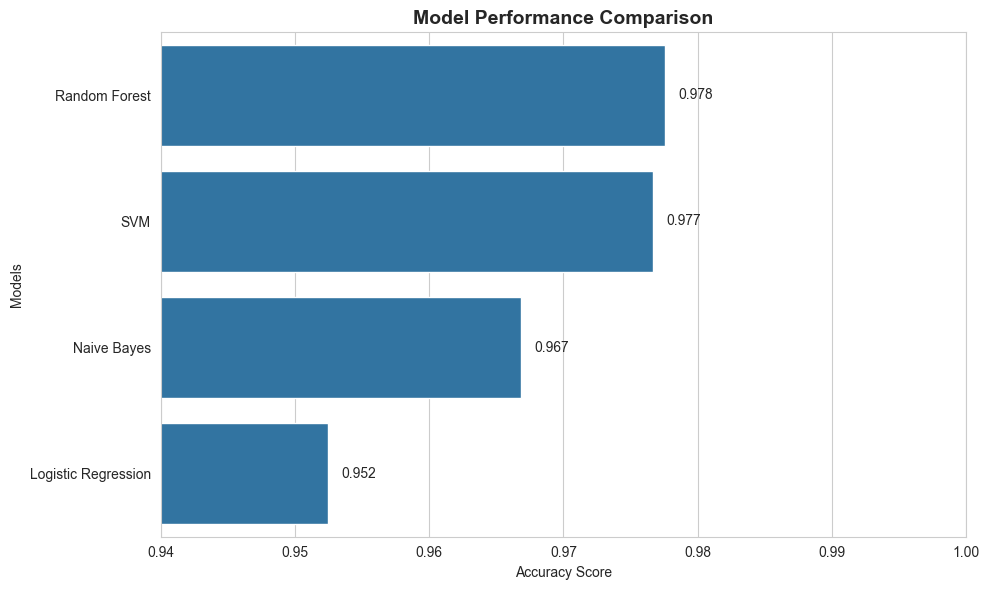

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest'],
    'Accuracy': [acc_lr, acc_nb, acc_svm, acc_rf]
})

results = results.sort_values(by='Accuracy', ascending=False)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results, x='Accuracy', y='Model')

# Add accuracy labels
for i, v in enumerate(results['Accuracy']):
    ax.text(v + 0.001, i, f"{v:.3f}", va='center')

# Titles and labels
plt.title("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Accuracy Score")
plt.ylabel("Models")

plt.xlim(0.94, 1.0)

plt.tight_layout()
plt.show()

### Model Comparison

In [66]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest'],
    'Accuracy': [acc_lr, acc_nb, acc_svm, acc_rf]
})

# Sort by accuracy
results = results.sort_values(by='Accuracy', ascending=False)

print(results)

                 Model  Accuracy
2                  SVM  0.975785
3        Random Forest  0.973991
1          Naive Bayes  0.965919
0  Logistic Regression  0.957848


## Important Features (Top Words)

- Feature importance helps in identifying which words contribute the most to the classification of messages.
- Using the model coefficients, we can extract the most influential words that indicate spam messages. For example, words like "free", "win", "offer", and "prize" are often strong indicators of spam.
- This step improves interpretability and helps us understand how the model makes decisions.

In [67]:
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_spam = sorted(zip(coefs, feature_names), reverse=True)[:10]

print("Top spam words:")
for coef, word in top_spam:
    print(word)

Top spam words:
txt
mobile
free
claim
stop
www
uk
reply
new
text


### Output

In [69]:
sample = ["You won a free lottery prize"]

sample_tfidf = tfidf.transform(sample)
prediction = nb.predict(sample_tfidf)[0]

if prediction == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")


Prediction: Spam


#### How does model classify new message ?
The input text is first transformed using TF-IDF vectorization, and then the trained model predicts whether it belongs to spam or ham based on learned patterns in the training data